In [1]:
import uproot
import numpy as np
import awkward as ak

In [2]:
tr_TTLJ = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2018/Vcb_CTag/Central_Syst/Vcb_TTLJ_powheg.root:Mu/Central/Result_Tree")
tr_Vcb = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2018/Vcb_CTag/Central_Syst/Vcb_TTLJ_WtoCB_powheg.root:Mu/Central/Result_Tree")

In [4]:
print(tr_Vcb.keys())

['weight_b_tag', 'weight_b_tag_down_hf', 'weight_b_tag_up_hf', 'weight_b_tag_down_lf', 'weight_b_tag_up_lf', 'weight_b_tag_down_lfstats1', 'weight_b_tag_up_lfstats1', 'weight_b_tag_down_lfstats2', 'weight_b_tag_up_lfstats2', 'weight_b_tag_down_cferr1', 'weight_b_tag_up_cferr1', 'weight_b_tag_down_cferr2', 'weight_b_tag_up_cferr2', 'weight_b_tag_down_hfstats1', 'weight_b_tag_up_hfstats1', 'weight_b_tag_down_hfstats2', 'weight_b_tag_up_hfstats2', 'weight_c_tag', 'weight_c_tag_down_extrap', 'weight_c_tag_up_extrap', 'weight_c_tag_down_interp', 'weight_c_tag_up_interp', 'weight_c_tag_down_lhe_scale_muf', 'weight_c_tag_up_lhe_scale_muf', 'weight_c_tag_down_lhe_scale_mur', 'weight_c_tag_up_lhe_scale_mur', 'weight_c_tag_down_ps_fsr_fixed', 'weight_c_tag_up_ps_fsr_fixed', 'weight_c_tag_down_ps_isr_fixed', 'weight_c_tag_up_ps_isr_fixed', 'weight_c_tag_down_pu', 'weight_c_tag_up_pu', 'weight_c_tag_down_stat', 'weight_c_tag_up_stat', 'weight_c_tag_down_xsec_brunc_dyjets_b', 'weight_c_tag_up_xsec_

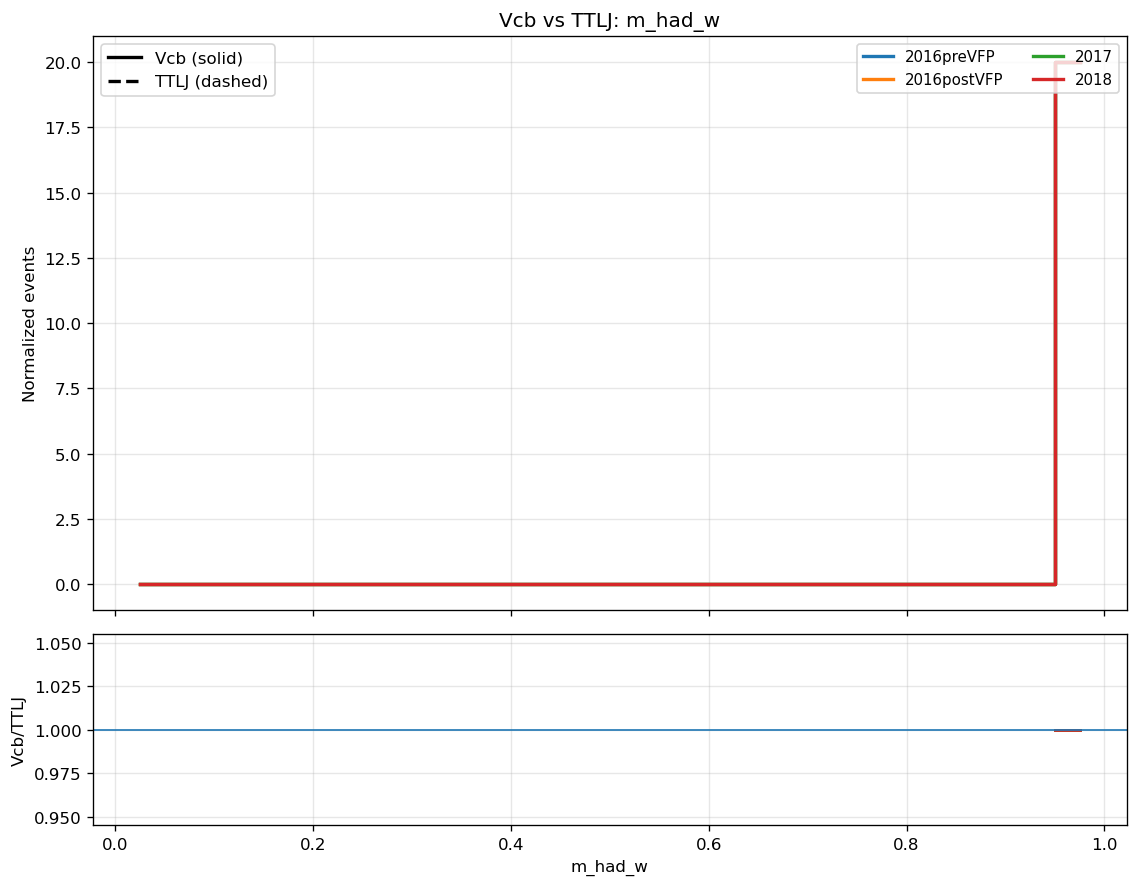

In [22]:
import uproot
import awkward as ak
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D


# -----------------------------
# 1) 트리 열기 (절대 경로)
# -----------------------------
# Vcb (W→cb)
tr_Vcb_2016a = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2016preVFP/Vcb_BTag_SPANet/Central_Syst/Vcb_TTLJ_WtoCB_powheg.root:Mu/Central/Result_Tree")
tr_Vcb_2016b = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2016postVFP/Vcb_BTag_SPANet//Central_Syst/Vcb_TTLJ_WtoCB_powheg.root:Mu/Central/Result_Tree")
tr_Vcb_2017  = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2017/Vcb_BTag_SPANet/Central_Syst/Vcb_TTLJ_WtoCB_powheg.root:Mu/Central/Result_Tree")
tr_Vcb_2018  = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2018/Vcb_BTag_SPANet/Central_Syst/Vcb_TTLJ_WtoCB_powheg.root:Mu/Central/Result_Tree")

# TTLJ
tr_TTLJ_2016a = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2016preVFP/Vcb_BTag_SPANet//Central_Syst/Vcb_TTLJ_powheg.root:Mu/Central/Result_Tree")
tr_TTLJ_2016b = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2016postVFP/Vcb_BTag_SPANet//Central_Syst/Vcb_TTLJ_powheg.root:Mu/Central/Result_Tree")
tr_TTLJ_2017  = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2017/Vcb_BTag_SPANet/Central_Syst/Vcb_TTLJ_powheg.root:Mu/Central/Result_Tree")
tr_TTLJ_2018  = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2018/Vcb_BTag_SPANet/Central_Syst/Vcb_TTLJ_powheg.root:Mu/Central/Result_Tree")

# -----------------------------
# 2) 필요한 브랜치 읽기
# -----------------------------
KEY = "m_had_w"
NEEDED = [KEY]

arr_Vcb_2016a = tr_Vcb_2016a.arrays(NEEDED, library="ak")
arr_Vcb_2016b = tr_Vcb_2016b.arrays(NEEDED, library="ak")
arr_Vcb_2017  = tr_Vcb_2017.arrays(NEEDED, library="ak")
arr_Vcb_2018  = tr_Vcb_2018.arrays(NEEDED, library="ak")

arr_TTLJ_2016a = tr_TTLJ_2016a.arrays(NEEDED, library="ak")
arr_TTLJ_2016b = tr_TTLJ_2016b.arrays(NEEDED, library="ak")
arr_TTLJ_2017  = tr_TTLJ_2017.arrays(NEEDED, library="ak")
arr_TTLJ_2018  = tr_TTLJ_2018.arrays(NEEDED, library="ak")

# -----------------------------
# 3) numpy 변환 + exp (log_prob -> prob)
# -----------------------------
def to_prob(x):
    x = ak.to_numpy(x)
    x = x[np.isfinite(x)]
    # 이미 [0,1] 범위면 그대로, 아니면 log-prob 가정하고 exp
    if (x.min() < 0) or (x.max() > 1):
        x = np.exp(np.clip(x, -30, 30))
    return np.clip(x, 1e-12, 1 - 1e-12)

Vcb = {
    "2016preVFP": to_prob(arr_Vcb_2016a[KEY]),
    "2016postVFP": to_prob(arr_Vcb_2016b[KEY]),
    "2017": to_prob(arr_Vcb_2017[KEY]),
    "2018": to_prob(arr_Vcb_2018[KEY]),
}
TTLJ = {
    "2016preVFP": to_prob(arr_TTLJ_2016a[KEY]),
    "2016postVFP": to_prob(arr_TTLJ_2016b[KEY]),
    "2017": to_prob(arr_TTLJ_2017[KEY]),
    "2018": to_prob(arr_TTLJ_2018[KEY]),
}

# ---------- 4') 한 플롯(상단 분포 + 하단 ratio) ----------
edges   = np.linspace(0.0, 1.0, 21)  # bin 더 촘촘히
centers = 0.5 * (edges[:-1] + edges[1:])
LOGY    = False

colors = {  # 연도별 고정 색
    "2016preVFP": "C0",
    "2016postVFP": "C1",
    "2017": "C2",
    "2018": "C3",
}

fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(9.5, 7.5), dpi=120,
    gridspec_kw={"height_ratios": [3, 1]}, sharex=True
)

for yr in ["2016preVFP", "2016postVFP", "2017", "2018"]:
    # 히스토그램 (density=True)
    hv, _ = np.histogram(Vcb[yr],  bins=edges, density=True)
    ht, _ = np.histogram(TTLJ[yr], bins=edges, density=True)

    # 상단: Vcb = 실선, TTLJ = 점선
    ax.step(centers, hv, where="mid", color=colors[yr], lw=2.0, ls="-",  label=f"{yr} Vcb")
    ax.step(centers, ht, where="mid", color=colors[yr], lw=1.8, ls="--", label=f"{yr} TTLJ")

    # 하단: ratio = Vcb / TTLJ
    ratio = np.divide(hv, ht, out=np.full_like(hv, np.nan), where=ht > 0)
    axr.step(centers, ratio, where="mid", color=colors[yr], lw=1.6)

# 스타일/레이블
ax.set_ylabel("Normalized events")
ax.set_title(f"Vcb vs TTLJ: {KEY}")
if LOGY:
    ax.set_yscale("log")
ax.grid(True, alpha=0.3)

axr.set_xlabel(KEY)      # <- 이전엔 f"KEY" 였던 버그 수정
axr.set_ylabel("Vcb/TTLJ")
axr.grid(True, alpha=0.3)
axr.axhline(1.0, lw=1.0)

# 범례를 2개로: (선스타일=프로세스), (색=연도)
proc_legend = [
    Line2D([0], [0], color="k", lw=2.0, ls="-",  label="Vcb (solid)"),
    Line2D([0], [0], color="k", lw=2.0, ls="--", label="TTLJ (dashed)"),
]
year_legend = [
    Line2D([0], [0], color=colors["2016preVFP"], lw=2, label="2016preVFP"),
    Line2D([0], [0], color=colors["2016postVFP"], lw=2, label="2016postVFP"),
    Line2D([0], [0], color=colors["2017"],       lw=2, label="2017"),
    Line2D([0], [0], color=colors["2018"],       lw=2, label="2018"),
]
leg1 = ax.legend(handles=proc_legend, loc="upper left")
leg2 = ax.legend(handles=year_legend, loc="upper right", ncol=2, fontsize=9)
ax.add_artist(leg1)

plt.tight_layout()
plt.show()

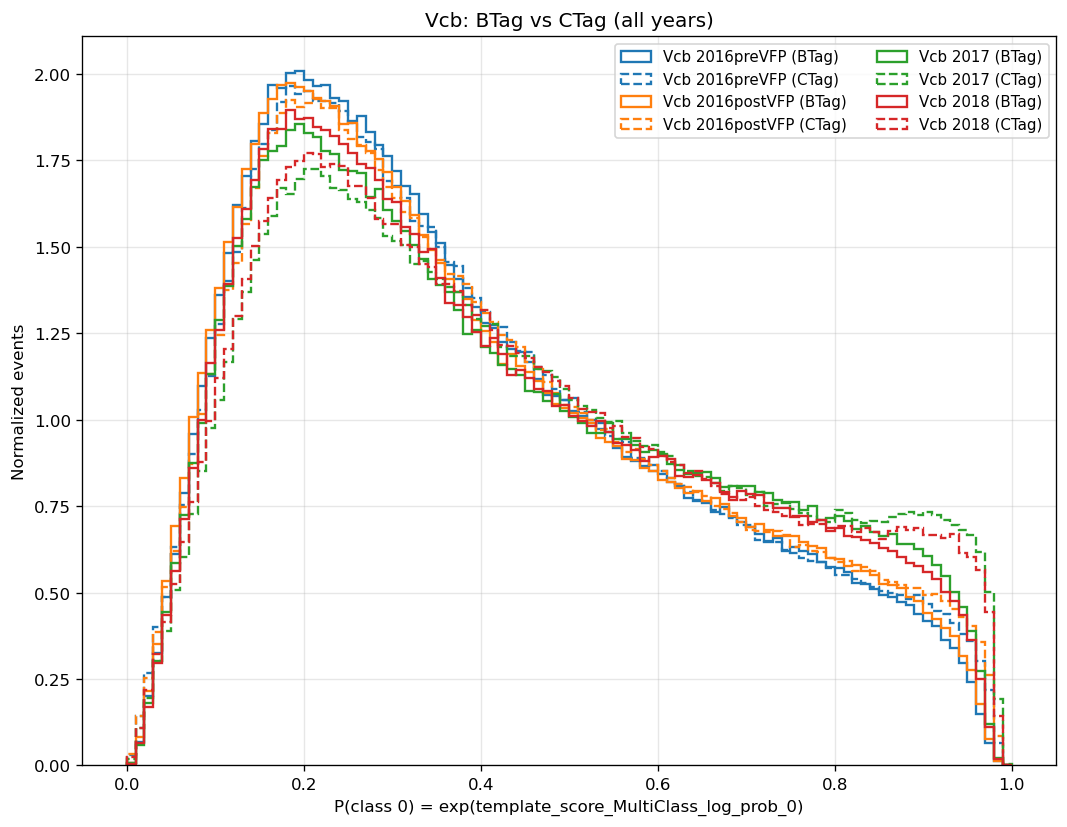

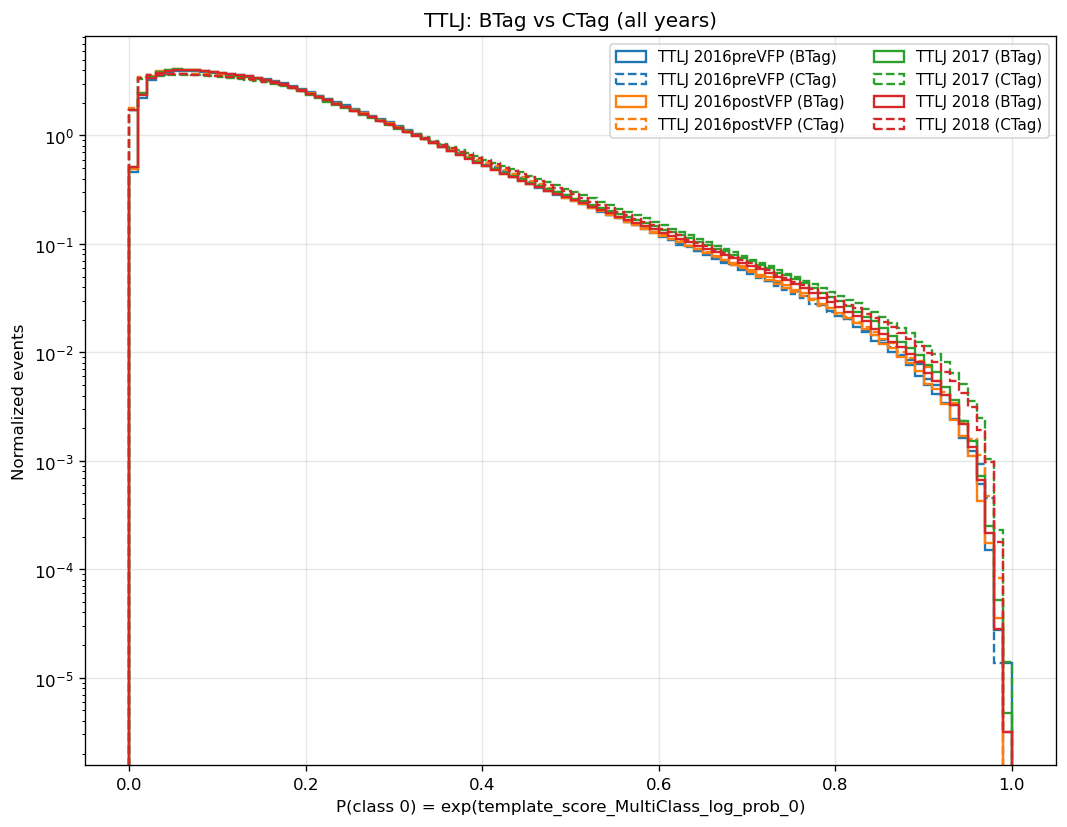

In [19]:
import uproot
import awkward as ak
import numpy as np
from matplotlib import pyplot as plt

# -----------------------------
# 공통 설정
# -----------------------------
BRANCH = "template_score_MultiClass_log_prob_0"
EDGE = np.linspace(0.0, 1.0, 101)
LOGY = False

YEARS = ["2016preVFP", "2016postVFP", "2017", "2018"]
# 파일 이름 패턴 (디렉토리 이름만 Vcb_BTag / Vcb_CTag로 바뀜)
FILENAMES = {
    "Vcb":  "Vcb_TTLJ_WtoCB_powheg.root",
    "TTLJ": "Vcb_TTLJ_powheg.root",
}
# 루트 트리 경로
TREEPATH = ":Mu/Central/Result_Tree"

def year_dir(y):
    return y  # 폴더 계층 그대로 사용

def tag_dir(tag):  # "BTag" or "CTag"
    return f"Vcb_{tag}"

def base_dir(y, tag):
    return f"/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/{year_dir(y)}/{tag_dir(tag)}/Central_Syst"

def file_path(y, tag, proc):
    return f"{base_dir(y, tag)}/{FILENAMES[proc]}{TREEPATH}"

def safe_open(path):
    try:
        return uproot.open(path)
    except Exception as e:
        print(f"[WARN] cannot open: {path}\n  -> {e}")
        return None

def safe_exp_1d(x):
    x = ak.to_numpy(x)
    x = x[np.isfinite(x)]
    x = np.clip(x, -1e3, 1e3)
    p = np.exp(x)
    return np.clip(p, 1e-12, 1.0)

def load_probs_by_year(tag, proc):
    """tag:'BTag'|'CTag', proc:'Vcb'|'TTLJ' -> dict[year] = np.ndarray(prob)"""
    out = {}
    for y in YEARS:
        path = file_path(y, tag, proc)
        tr = safe_open(path)
        if tr is None:
            continue
        arr = tr.arrays([BRANCH], library="ak")
        out[y] = safe_exp_1d(arr[BRANCH])
    return out

def plot_compare_B_vs_C(proc, edges=EDGE, logy=LOGY):
    """proc: 'Vcb' or 'TTLJ'"""
    probs_B = load_probs_by_year("BTag", proc)
    probs_C = load_probs_by_year("CTag", proc)

    plt.figure(figsize=(9, 7), dpi=120)
    # 동일 색으로 연도 표현, 선종류로 태그 구분
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', None)

    for i, y in enumerate(YEARS):
        color = color_cycle[i % len(color_cycle)] if color_cycle else None

        if y in probs_B:
            plt.hist(probs_B[y], bins=edges, histtype='step', density=True,
                     label=f"{proc} {y} (BTag)", linestyle='-', linewidth=1.4, color=color)
        if y in probs_C:
            plt.hist(probs_C[y], bins=edges, histtype='step', density=True,
                     label=f"{proc} {y} (CTag)", linestyle='--', linewidth=1.4, color=color)

    plt.xlabel(f"P(class 0) = exp({BRANCH})")
    plt.ylabel("Normalized events")
    plt.title(f"{proc}: BTag vs CTag (all years)")
    if logy:
        plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 실행: Vcb / TTLJ 각각 그리기
# -----------------------------
plot_compare_B_vs_C("Vcb")
plot_compare_B_vs_C("TTLJ", logy=True)  # 테일 확인하려면 True


In [ ]:
import uproot
import awkward as ak
import numpy as np
from matplotlib import pyplot as plt
from itertools import combinations

# -----------------------------
# 0) 설정
# -----------------------------
KEY = "bvsc_w_d"        # 그릴 변수
IS_LOGPROB = False     # KEY가 log-prob이면 True (exp 적용)

# genTtbarId로 HF 판정: 기본은 gid>=50, 필요 시 HF_IDS에 정확 매핑 넣어 사용
HF_IDS = None  # 예: {51, 52, 53, 54, 41, 42, 43}
def is_hf_gid(gid: int) -> bool:
    if HF_IDS is not None:
        return gid in HF_IDS
    return gid >= 50  # 기본 규칙(필요시 수정)

# -----------------------------
# 1) 트리 열기 (2017만)
# -----------------------------
tr_Vcb_2017  = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2017/Vcb_BTag_SPANet/Central_Syst/Vcb_TTLJ_WtoCB_powheg.root:Mu/Central/Result_Tree")
tr_TTLJ_2017 = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2017/Vcb_BTag_SPANet/Central_Syst/Vcb_TTLJ_powheg.root:Mu/Central/Result_Tree")

# -----------------------------
# 2) 필요한 브랜치 읽기
# -----------------------------
arr_Vcb_2017  = tr_Vcb_2017.arrays([KEY], library="ak")
arr_TTLJ_2017 = tr_TTLJ_2017.arrays([KEY, "genTtbarId"], library="ak")

def to_value(x, is_logprob=False):
    x = ak.to_numpy(x)
    x = x[np.isfinite(x)]
    if is_logprob:
        x = np.exp(np.clip(x, -30, 30))
        x = np.clip(x, 1e-12, 1 - 1e-12)
    return x

# Vcb 값
vcb_vals = to_value(arr_Vcb_2017[KEY], is_logprob=IS_LOGPROB)

# TTLJ 값 + genTtbarId로 분리
ttlj_vals_all = ak.to_numpy(arr_TTLJ_2017[KEY])
ttlj_gid_all  = ak.to_numpy(arr_TTLJ_2017["genTtbarId"])

finite_mask = np.isfinite(ttlj_vals_all) & np.isfinite(ttlj_gid_all)
ttlj_vals_all = ttlj_vals_all[finite_mask]
ttlj_gid_all  = ttlj_gid_all[finite_mask]

if IS_LOGPROB:
    ttlj_vals_all = np.exp(np.clip(ttlj_vals_all, -30, 30))
    ttlj_vals_all = np.clip(ttlj_vals_all, 1e-12, 1 - 1e-12)

hf_mask  = np.vectorize(is_hf_gid)(ttlj_gid_all)
lf_mask  = ~hf_mask

ttlj_hf  = ttlj_vals_all[hf_mask]
ttlj_lf  = ttlj_vals_all[lf_mask]

print(f"[Counts] 2017  Vcb={len(vcb_vals)}, TTLJ(HF)={len(ttlj_hf)}, TTLJ(non-HF)={len(ttlj_lf)}")

# -----------------------------
# 3) 히스토그램 설정 (변수 스케일에 따라 자동)
# -----------------------------
if IS_LOGPROB:
    edges = np.linspace(0.0, 1.0, 21)
else:
    all_vals = np.concatenate([vcb_vals, ttlj_hf, ttlj_lf]) if len(ttlj_hf) and len(ttlj_lf) else vcb_vals
    lo, hi = np.percentile(all_vals, [0.5, 99.5])  # 아웃라이어 약간 제외
    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        lo, hi = (np.nanmin(all_vals), np.nanmax(all_vals))
    nbins = 40
    edges = np.linspace(lo, hi, nbins + 1)

centers = 0.5 * (edges[:-1] + edges[1:])

# -----------------------------
# 4) 히스토그램 계산 (density=True)
# -----------------------------
hv, _   = np.histogram(vcb_vals,  bins=edges, density=True)
hhf, _  = np.histogram(ttlj_hf,   bins=edges, density=True)
hlf, _  = np.histogram(ttlj_lf,   bins=edges, density=True)

# -----------------------------
# 5) 플로팅 (상단 분포 + 하단 ratio 2줄)
# -----------------------------
fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(9.5, 7.5), dpi=120,
    gridspec_kw={"height_ratios": [3, 1]}, sharex=True
)

# 상단: Vcb / TTLJ(HF) / TTLJ(non-HF)
ax.step(centers, hv,  where="mid", lw=2.2, ls="-",  color="k",  label="Vcb (2017)")
ax.step(centers, hhf, where="mid", lw=2.0, ls="--", color="C1", label="TTLJ + HF (2017)")
ax.step(centers, hlf, where="mid", lw=2.0, ls=":",  color="C0", label="TTLJ non-HF (2017)")

ax.set_ylabel("Normalized events")
ax.set_title(f"2017 comparison: {KEY}  (Vcb vs TTLJ[HF/non-HF])")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

# 하단: ratio (Vcb/TTLJ-HF, Vcb/TTLJ-nonHF)
ratio_hf = np.divide(hv, hhf, out=np.full_like(hv, np.nan), where=hhf > 0)
ratio_lf = np.divide(hv, hlf, out=np.full_like(hv, np.nan), where=hlf > 0)

axr.step(centers, ratio_hf, where="mid", lw=1.8, color="C1", label="Vcb / (TTLJ+HF)")
axr.step(centers, ratio_lf, where="mid", lw=1.8, color="C0", label="Vcb / (TTLJ non-HF)")

axr.axhline(1.0, lw=1.0, color="gray")
axr.set_xlabel(KEY)
axr.set_ylabel("Ratio")
axr.grid(True, alpha=0.3)
axr.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()
